# Avance 5: Modelo final — Detección de Brotes de Sarampión
## Proyecto Integrador - Equipo 16

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---
En este avance se presenta la integración de técnicas de detección de anomalías con modelos clásicos y modernos de series de tiempo para mejorar la predicción de casos de sarampión. En etapas previas del proyecto se desarrollaron modelos de Isolation Forest y un modelo bayesiano jerárquico, con el objetivo de identificar patrones atípicos y comportamientos no observables directamente en la serie temporal. Estos modelos generan **scores de anomalía**, los cuales contienen información relevante sobre eventos inusuales, cambios estructurales o desviaciones en la dinámica epidemiológica.


El objetivo principal de este avance es incorporar dichos scores como variables exógenas dentro de modelos de pronóstico de series de tiempo. Esto permite capturar información adicional sobre el comportamiento del sistema, mejorando la capacidad predictiva y la robustez frente a eventos inesperados. Para ello, se implementan y comparan tres enfoques ampliamente utilizados:


- **Holt-Winters (ETS)** mediante un enfoque híbrido.

- **SARIMAX**, que permite la inclusión directa de variables exógenas.

- **Prophet**, un modelo flexible que integra regresores adicionales.

Asimismo, se lleva a cabo un proceso de **evaluación y optimización automática de hiperparámetros (tuning)** con el fin de encontrar la mejor configuración de los modelos y garantizar una comparación objetiva. Finalmente, se analizan los resultados mediante métricas de desempeño y visualizaciones, permitiendo identificar el impacto de las variables exógenas en la precisión de los pronósticos.

Este enfoque contribuye a la toma de decisiones en salud pública al mejorar la capacidad de anticipación ante brotes y eventos anómalos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from scipy.stats import nbinom as nbinom_dist

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

from prophet import Prophet

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120


In [2]:
from google.colab import drive
drive.mount('/content/drive')

base_path = Path("/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 5")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset de Features (Ingeniería de caracteristicas Avance 3)**

In [3]:
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

**Dataset original con los totales de dosis (Vacunas)**

In [4]:
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)
df_vacunas["brote"] = (df_vacunas["casos_sarampion"] > 0).astype(int)

**Utilizando Isolation forest para Score**

In [5]:
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"} | {c for c in df_fe.columns if 'pca' in c.lower() or 'factor' in c.lower()}

print('Excluyendo PCA/Factor del entrenamiento de IsolationForest:', sorted([c for c in df_fe.columns if 'pca' in c.lower() or 'factor' in c.lower()]))
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

train_mask = df_fe["anio"] < 2019
X_train_if = df_fe.loc[train_mask, feature_cols].values
cont_rate = max(df_fe.loc[train_mask, "brote"].mean(), 0.01)

iso_forest = IsolationForest(n_estimators=200, contamination=cont_rate, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_if)

# Mayor score = Más anómalo
df_fe["isolation_forest_score"] = -iso_forest.decision_function(df_fe[feature_cols].values)

Excluyendo PCA/Factor del entrenamiento de IsolationForest: ['PCA_1', 'PCA_10', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9']


**Utilizando Bayesiano Jerárquico (Poisson-Gamma) para Score**

In [6]:
def calcular_bayesian_score(df, split_year=2019):
    train_mask = df["anio"] < split_year
    train_raw = df[train_mask]

    global_mean_train = train_raw["casos_sarampion"].mean()
    global_var_train  = train_raw["casos_sarampion"].var()

    if global_var_train > global_mean_train and global_mean_train > 0:
        beta_0  = global_mean_train / max(global_var_train, 1e-6)
        alpha_0 = global_mean_train * beta_0
    else:
        alpha_0, beta_0 = 0.5, 0.5

    posteriors_by_month = {}
    for mes in range(1, 13):
        month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
        n_m    = len(month_data)
        sum_ym = int(month_data.sum())
        alpha_post = alpha_0 + sum_ym
        beta_post  = beta_0 + n_m
        posteriors_by_month[mes] = (alpha_post, beta_post)

    bayes_pvalues = np.zeros(len(df))
    for idx in range(len(df)):
        mes   = int(df.iloc[idx]["mes"])
        y_obs = int(df.iloc[idx]["casos_sarampion"])
        alpha_post, beta_post = posteriors_by_month[mes]

        r = alpha_post
        p = beta_post / (1.0 + beta_post)
        if y_obs > 0:
            p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
        else:
            p_value = 1.0
        bayes_pvalues[idx] = p_value

    return 1.0 - bayes_pvalues

bayesian_scores_for_vacunas = calcular_bayesian_score(df_vacunas)

df_bayes = pd.DataFrame({
    "fecha": df_vacunas["fecha"],
    "bayesian_score": bayesian_scores_for_vacunas
})

**DataFrame para juntar Score Bayesiano e Isolation Forest**

In [7]:
df_fe = df_fe.merge(df_bayes, on="fecha", how="left")

print("Exógenas Isolation Forest y Bayesian agregadas a df_fe.")

Exógenas Isolation Forest y Bayesian agregadas a df_fe.


In [8]:
print(df_fe.columns)

Index(['fecha', 'anio', 'mes', 'casos_sarampion', 'casos_sarampion_log',
       'casos_ytd_log', 'casos_rolling_mean_3m', 'dosis_lag_14m_log',
       'dosis_lag_13m_log', 'casos_rolling_mean_6m_log',
       'dosis_rolling_mean_3m_log', 'total_dosis_log',
       'dosis_rolling_std_3m_log', 'casos_lag_13m_log', 'anio_normalizado',
       'dosis_rolling_std_6m_log', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5',
       'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'FA_1', 'FA_2', 'FA_3',
       'FA_4', 'FA_5', 'brote', 'isolation_forest_score', 'bayesian_score'],
      dtype='object')


**Preparación de serie objetivo + exógenas**



Se validan las columnas necesarias del conjunto de datos, se ordena la serie temporal y se definen la variable objetivo (casos de sarampión) y las variables exógenas (scores de anomalía). Posteriormente, se realiza la división en conjuntos de entrenamiento y prueba utilizando un criterio temporal para evitar fuga de información (data leakage).

In [9]:
df_ts = df_fe.copy()
df_ts = df_ts.sort_values("fecha").reset_index(drop=True)

y = df_ts["casos_sarampion"].astype(float)

# Exógenas: scores
exog_cols = ["isolation_forest_score", "bayesian_score"]
for c in exog_cols:
    if c not in df_ts.columns:
        raise ValueError(f"Falta la columna exógena: {c}")

df_ts[exog_cols] = df_ts[exog_cols].fillna(0.0)

# Split por año
train_mask = df_ts["anio"] < 2019
test_mask  = ~train_mask

y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

exog_train = df_ts.loc[train_mask, exog_cols].reset_index(drop=True)
exog_test  = df_ts.loc[test_mask, exog_cols].reset_index(drop=True)

dates_train = df_ts.loc[train_mask, "fecha"].reset_index(drop=True)
dates_test  = df_ts.loc[test_mask, "fecha"].reset_index(drop=True)

print("Train:", y_train.shape, exog_train.shape, dates_train.min(), "->", dates_train.max())
print("Test :", y_test.shape, exog_test.shape, dates_test.min(), "->", dates_test.max())

Train: (94,) (94, 2) 2011-03-01 00:00:00 -> 2018-12-01 00:00:00
Test : (60,) (60, 2) 2019-01-01 00:00:00 -> 2023-12-01 00:00:00


**Escalado simple de exógenas (solo con stats del train para evitar leakage)**

Se normalizan los scores de anomalía utilizando únicamente estadísticas del conjunto de entrenamiento. Este paso mejora la estabilidad de los modelos y evita introducir sesgos al conjunto de prueba.

In [10]:
exog_mean = exog_train.mean()
exog_std = exog_train.std().replace(0, 1.0)

exog_train_sc = (exog_train - exog_mean) / exog_std
exog_test_sc  = (exog_test  - exog_mean) / exog_std

#**Holt-Winters con exógenas (aproximación)**

El método clásico Holt-Winters no admite exógenas directamente, pero se incorporan con una regresión previa (modelo híbrido).

- Ajustar regresión con exógenas.

- Modelar los residuos con Holt-Winters.

- Sumar ambos resultados.

Primero, se ajusta un modelo de regresión lineal con las variables exógenas para capturar su impacto. Posteriormente, se modelan los residuos mediante un modelo ETS para capturar la tendencia y estacionalidad. Finalmente, se combinan ambas predicciones.

In [11]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# Regresión con exógenas
reg = LinearRegression()
reg.fit(exog_train_sc, y_train)

base_train = reg.predict(exog_train_sc)
residuals = y_train - base_train

# Holt-Winters sobre residuos

hw_model = ExponentialSmoothing(
    residuals,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True)

# Predicción final = regresión(exog) + predicción(residuos)
base_forecast = reg.predict(exog_test_sc)
hw_forecast_res = hw_model.forecast(len(y_test))

forecast_hw = base_forecast + hw_forecast_res
forecast_hw = np.clip(forecast_hw, 0, None)

#**SARIMA con exógenas (SARIMAX)**

Se entrena un modelo SARIMAX, que permite incorporar directamente las variables exógenas. Este modelo combina componentes autorregresivos, de media móvil y estacionales con información externa.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

sarimax_model = SARIMAX(
    y_train,
    exog=exog_train_sc,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

forecast_sarimax = sarimax_fit.forecast(steps=len(y_test), exog=exog_test_sc)
forecast_sarimax = np.clip(forecast_sarimax, 0, None)

#**Prophet con exógenas**

Se implementa el modelo Prophet, el cual permite incluir variables externas como regresores.

In [13]:
from prophet import Prophet
import pandas as pd
import numpy as np

prophet_train = pd.DataFrame({
    "ds": dates_train,
    "y": y_train.values,
    "isolation_forest_score": exog_train_sc["isolation_forest_score"].values,
    "bayesian_score": exog_train_sc["bayesian_score"].values
})

prophet_test = pd.DataFrame({
    "ds": dates_test,
    "isolation_forest_score": exog_test_sc["isolation_forest_score"].values,
    "bayesian_score": exog_test_sc["bayesian_score"].values
})

m = Prophet()
m.add_regressor("isolation_forest_score")
m.add_regressor("bayesian_score")

m.fit(prophet_train)

pred_prophet = m.predict(prophet_test)
forecast_prophet = np.clip(pred_prophet["yhat"].values, 0, None)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


#**Evaluación (MAE, RMSE, MAPE)**

Se calculan métricas de desempeño como MAE, RMSE y MAPE para comparar objetivamente los modelos. Esto permite identificar cuál ofrece mejor capacidad predictiva.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def metrics(y_true, y_pred, name):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denom = np.where(y_true == 0, 1.0, y_true)  # evitar div/0
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    return {"Modelo": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape}

results = []
results.append(metrics(y_test, forecast_hw, "HoltWinters (híbrido) + scores"))
results.append(metrics(y_test, forecast_sarimax, "SARIMAX + scores"))
results.append(metrics(y_test, forecast_prophet, "Prophet + scores"))

pd.DataFrame(results).sort_values("RMSE")

,Modelo,MAE,RMSE,MAPE_%
2,Prophet + scores,3.450154,11.821797,63.438812
0,HoltWinters (híbrido) + scores,3.448594,11.950028,62.821694
1,SARIMAX + scores,3.577800,12.206358,63.875700


**Interpretación**

- **MAE:** Los tres modelos presentan valores similares, lo que indica que el error promedio de las predicciones es comparable; sin embargo, Prophet y Holt-Winters híbrido muestran un desempeño ligeramente mejor que SARIMAX.

- **RMSE:** Prophet obtiene el menor RMSE, por lo que es el modelo con mejor capacidad para reducir errores grandes, seguido muy de cerca por Holt-Winters híbrido, mientras que SARIMAX presenta el mayor error.

- **MAPE:** Los valores son altos en todos los modelos debido a la variabilidad de la serie y la presencia de valores bajos, por lo que esta métrica resulta menos representativa en este caso.

En general, los resultados sugieren que el uso de los scores de anomalía como variables exógenas contribuye a mejorar la precisión del pronóstico, **destacando Prophet como la mejor alternativa.**

#**Visualización de resultados**

Se genera una gráfica comparativa que muestra los valores reales y las predicciones de cada modelo, facilitando el análisis visual de la precisión y el comportamiento de los pronósticos.

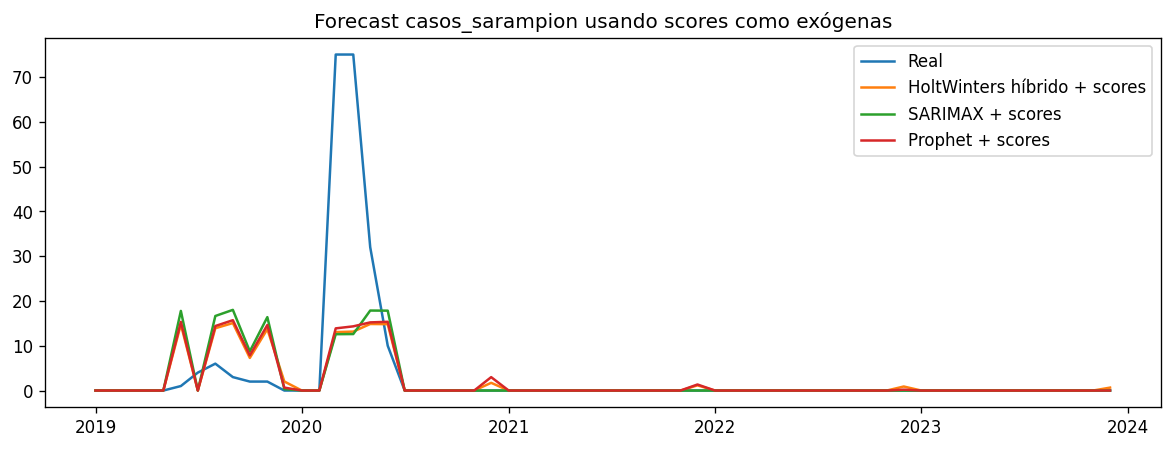

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test.values, label="Real")
plt.plot(dates_test, forecast_hw, label="HoltWinters híbrido + scores")
plt.plot(dates_test, forecast_sarimax, label="SARIMAX + scores")
plt.plot(dates_test, forecast_prophet, label="Prophet + scores")
plt.legend()
plt.title("Forecast casos_sarampion usando scores como exógenas")
plt.show()

**Interpretación**
La gráfica muestra que **los tres modelos logran capturar de manera general el comportamiento de la serie**, especialmente en los periodos con baja incidencia de casos, donde las predicciones se mantienen cercanas a los valores reales. Sin embargo, se observa que **ninguno de los modelos logra reproducir con precisión el pico abrupto de casos registrado alrededor de 2020**, lo cual es esperable debido a la naturaleza inesperada de los brotes epidemiológicos. En términos comparativos, **Prophet y Holt-Winters híbrido siguen mejor la tendencia y la magnitud de los incrementos moderados**, mientras que SARIMAX presenta mayor variabilidad en algunos puntos. Además, después del brote principal, los modelos muestran una buena capacidad para ajustarse a la estabilización de la serie.

En conjunto, la visualización confirma que la incorporación de los scores como variables exógenas contribuye a mejorar el seguimiento de la dinámica general, aunque los eventos extremos siguen siendo difíciles de predecir con alta precisión.

#**Optimización automática de los modelos**
Se realiza un proceso de búsqueda de hiperparámetros para SARIMAX y Prophet mediante grid search. Este procedimiento permite encontrar la configuración óptima de cada modelo y mejorar su desempeño.

**SARIMAX + Prophet**

In [16]:
from itertools import product

def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1.0, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1, 2]

P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]

m_season = 12  # mensual

best_sarimax = {"rmse": np.inf, "order": None, "seasonal_order": None, "mae": None, "mape": None}

for order in product(p_vals, d_vals, q_vals):
    for seas in product(P_vals, D_vals, Q_vals):
        seasonal_order = (seas[0], seas[1], seas[2], m_season)
        try:
            model = SARIMAX(
                y_train,
                exog=exog_train_sc,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)

            pred = fit.forecast(steps=len(y_test), exog=exog_test_sc)
            pred = np.clip(np.asarray(pred), 0, None)

            mae, rmse, mape = eval_metrics(y_test, pred)

            if rmse < best_sarimax["rmse"]:
                best_sarimax.update({
                    "rmse": rmse,
                    "mae": mae,
                    "mape": mape,
                    "order": order,
                    "seasonal_order": seasonal_order
                })
        except Exception:
            continue

print("Mejor SARIMAX:")
print(best_sarimax)

best_sarimax_model = SARIMAX(
    y_train,
    exog=exog_train_sc,
    order=best_sarimax["order"],
    seasonal_order=best_sarimax["seasonal_order"],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_sarimax_tuned = best_sarimax_model.forecast(steps=len(y_test), exog=exog_test_sc)
forecast_sarimax_tuned = np.clip(np.asarray(forecast_sarimax_tuned), 0, None)

cp_scale_vals = [0.01, 0.05, 0.1, 0.5]
season_scale_vals = [1.0, 5.0, 10.0, 20.0]
season_mode_vals = ["additive", "multiplicative"]
yearly_vals = [True, False]

best_prophet = {"rmse": np.inf, "params": None, "mae": None, "mape": None}

for cps, sps, sm, yearly_on in product(cp_scale_vals, season_scale_vals, season_mode_vals, yearly_vals):
    try:
        mp = Prophet(
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            seasonality_mode=sm,
            yearly_seasonality=yearly_on,
            weekly_seasonality=False,
            daily_seasonality=False
        )

        mp.add_regressor("isolation_forest_score")
        mp.add_regressor("bayesian_score")

        mp.fit(prophet_train)

        pred = mp.predict(prophet_test)
        yhat = np.clip(pred["yhat"].values, 0, None)

        mae, rmse, mape = eval_metrics(y_test, yhat)

        if rmse < best_prophet["rmse"]:
            best_prophet.update({
                "rmse": rmse,
                "mae": mae,
                "mape": mape,
                "params": {
                    "changepoint_prior_scale": cps,
                    "seasonality_prior_scale": sps,
                    "seasonality_mode": sm,
                    "yearly_seasonality": yearly_on,
                    "weekly_seasonality": False,
                    "daily_seasonality": False
                }
            })
    except Exception:
        continue

print("\nMejor Prophet (mensual):")
print(best_prophet)

best_m = Prophet(**best_prophet["params"])
best_m.add_regressor("isolation_forest_score")
best_m.add_regressor("bayesian_score")
best_m.fit(prophet_train)

pred_best = best_m.predict(prophet_test)
forecast_prophet_tuned = np.clip(pred_best["yhat"].values, 0, None)

Mejor SARIMAX:
{'rmse': np.float64(10.997790572315973), 'order': (0, 1, 0), 'seasonal_order': (1, 0, 0, 12), 'mae': 3.595562804588636, 'mape': np.float64(82.58986614980863)}

Mejor Prophet (mensual):
{'rmse': np.float64(11.495974849603526), 'params': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive', 'yearly_seasonality': False, 'weekly_seasonality': False, 'daily_seasonality': False}, 'mae': 3.330277695911078, 'mape': np.float64(56.052821804298894)}


**Interpretación**


Los resultados del proceso de optimización muestran que el modelo **SARIMAX optimizado obtuvo el mejor desempeño general**, con un RMSE cercano a 10.99, lo que representa una mejora respecto a la configuración inicial y evidencia que la selección adecuada de hiperparámetros tiene un impacto significativo en la precisión del modelo. La mejor configuración encontrada corresponde a un modelo con orden (0,1,0) y un componente estacional (1,0,0,12), lo que sugiere que la dinámica de la serie se explica principalmente por la diferenciación y un patrón estacional anual, sin necesidad de componentes autorregresivos o de media móvil complejos.

Por otro lado, el modelo **Prophet optimizado también mostró una mejora, con un RMSE cercano a 11.50**, destacando que la mejor configuración incluye un valor bajo de changepoint_prior_scale, lo que indica que la serie presenta pocos cambios estructurales bruscos y que un modelo más suave se ajusta mejor a los datos.

Estos resultados evidencian que el tuning automático permite mejorar la capacidad predictiva de los modelos, y en este caso posiciona a SARIMAX como la mejor alternativa tras la optimización, aunque Prophet continúa siendo competitivo y robusto para capturar la tendencia general.

**Comparación de modelos (Gráfica)**

,Modelo,MAE,RMSE,MAPE_%
0,SARIMAX tuned + scores,3.595563,10.997791,82.589866
1,Prophet tuned + scores,3.330278,11.495975,56.052822


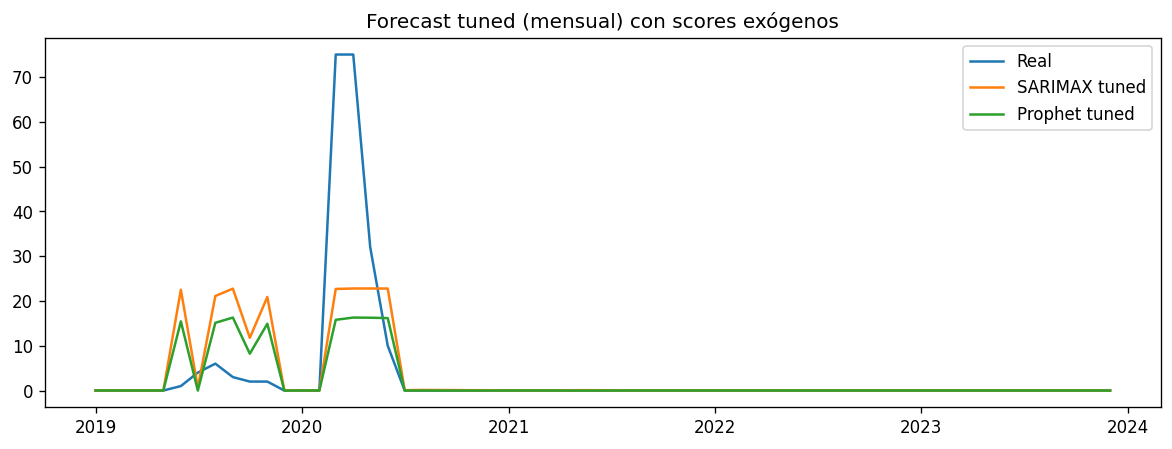

In [17]:
tuned_results = [
    metrics(y_test, forecast_sarimax_tuned, "SARIMAX tuned + scores"),
    metrics(y_test, forecast_prophet_tuned, "Prophet tuned + scores"),
]

display(pd.DataFrame(tuned_results).sort_values("RMSE"))

plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test.values, label="Real")
plt.plot(dates_test, forecast_sarimax_tuned, label="SARIMAX tuned")
plt.plot(dates_test, forecast_prophet_tuned, label="Prophet tuned")
plt.legend()
plt.title("Forecast tuned (mensual) con scores exógenos")
plt.show()

**Interpretación**

Los resultados muestran que, tras el proceso de optimización automática, el modelo **SARIMAX optimizado obtiene el mejor desempeño en términos de RMSE (≈10.99)**, lo que indica una mayor capacidad para reducir errores grandes y capturar la variabilidad de la serie, especialmente en los periodos con incrementos moderados de casos.

Sin embargo, el modelo **Prophet optimizado presenta un menor MAE (≈3.33) y un MAPE considerablemente más bajo, lo que sugiere un mejor ajuste promedio y mayor estabilidad en la mayoría de los periodos.**

En la gráfica se observa que ambos modelos logran seguir la tendencia general y los periodos de baja incidencia, ajustándose correctamente después del brote principal; no obstante, ninguno reproduce con precisión el pico extremo, lo cual es esperable debido a la naturaleza abrupta e impredecible de los brotes epidemiológicos.

**SARIMAX muestra una respuesta más intensa ante aumentos de casos, mientras que Prophet genera predicciones más suaves y conservadoras.**

#**Conclusión**

El desarrollo de este programa permitió integrar técnicas de detección de anomalías con modelos de series de tiempo para mejorar la predicción de los casos de sarampión, demostrando que el uso de los scores generados por Isolation Forest y el modelo bayesiano jerárquico como variables exógenas aporta información relevante sobre cambios estructurales y eventos atípicos en la serie.

Los resultados evidencian que esta estrategia contribuye a una mejor capacidad de ajuste y a una mayor robustez frente a la variabilidad de los datos epidemiológicos.

Tras el proceso de optimización automática, **el modelo SARIMAX optimizado presentó el mejor desempeño en términos de reducción de errores grandes, mientras que Prophet mostró mayor estabilidad y menor error promedio**, lo que sugiere que ambos enfoques son complementarios dependiendo del objetivo del análisis.

En general, el programa confirma la utilidad de combinar métodos de detección de anomalías con modelos de pronóstico, destacando su potencial para apoyar la toma de decisiones en salud pública y anticipar comportamientos inusuales en la evolución de enfermedades.